# Import and Install

In [23]:
# !pip install fastparquet imbalanced-learn matplotlib seaborn pyarrow xgboost lightgbm catboost scikit-learn==1.8.0 cleanlab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import pyarrow as pa
import pyarrow.parquet as pq
import random
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler

In [ ]:
FEATURE_COLUMNS = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Fwd Packet Length Std", "Bwd Packet Length Min", "Bwd Packet Length Std",
    "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Min", "Fwd PSH Flags",
    "Fwd Header Length", "Fwd Packets/s", "SYN Flag Count", "ACK Flag Count",
    "URG Flag Count", "CWE Flag Count", "Init_Win_bytes_forward",
    "act_data_pkt_fwd", "min_seg_size_forward", "Active Mean", "Idle Mean",
]

COLUMN_RENAME_MAP = {
    "flow_duration": "Flow Duration", "tot_fwd_pkts": "Total Fwd Packets",
    "tot_bwd_pkts": "Total Backward Packets", "totlen_fwd_pkts": "Total Length of Fwd Packets",
    "totlen_bwd_pkts": "Total Length of Bwd Packets", "fwd_pkt_len_std": "Fwd Packet Length Std",
    "bwd_pkt_len_min": "Bwd Packet Length Min", "bwd_pkt_len_std": "Bwd Packet Length Std",
    "flow_iat_min": "Flow IAT Min", "fwd_iat_tot": "Fwd IAT Total",
    "fwd_iat_min": "Fwd IAT Min", "fwd_psh_flags": "Fwd PSH Flags",
    "fwd_header_len": "Fwd Header Length", "fwd_pkts_s": "Fwd Packets/s",
    "syn_flag_cnt": "SYN Flag Count", "ack_flag_cnt": "ACK Flag Count",
    "urg_flag_cnt": "URG Flag Count", "cwr_flag_count": "CWE Flag Count",
    "init_fwd_win_byts": "Init_Win_bytes_forward", "fwd_act_data_pkts": "act_data_pkt_fwd",
    "fwd_seg_size_min": "min_seg_size_forward", "active_mean": "Active Mean",
    "idle_mean": "Idle Mean",
}


def generate_synthetic_ddos_flow_data(
    num_attackers: int = 1000,
    min_attacks: int = 50,
    max_attacks: int = 100,
    server_ip: str = "192.168.1.10",
) -> pd.DataFrame:
    """Generate synthetic DDoS flow records resembling ddosflowgen output."""

    columns = [
        "src_ip", "dst_ip", "src_port", "dst_port", "protocol", "timestamp", "flow_duration", "flow_byts_s",
        "flow_pkts_s", "fwd_pkts_s", "bwd_pkts_s", "tot_fwd_pkts", "tot_bwd_pkts", "totlen_fwd_pkts",
        "totlen_bwd_pkts", "fwd_pkt_len_max", "fwd_pkt_len_min", "fwd_pkt_len_mean", "fwd_pkt_len_std",
        "bwd_pkt_len_max", "bwd_pkt_len_min", "bwd_pkt_len_mean", "bwd_pkt_len_std", "pkt_len_max",
        "pkt_len_min", "pkt_len_mean", "pkt_len_std", "pkt_len_var", "fwd_header_len", "bwd_header_len",
        "fwd_seg_size_min", "fwd_act_data_pkts", "flow_iat_mean", "flow_iat_max", "flow_iat_min", "flow_iat_std",
        "fwd_iat_tot", "fwd_iat_max", "fwd_iat_min", "fwd_iat_mean", "fwd_iat_std", "bwd_iat_tot", "bwd_iat_max",
        "bwd_iat_min", "bwd_iat_mean", "bwd_iat_std", "fwd_psh_flags", "bwd_psh_flags", "fwd_urg_flags",
        "bwd_urg_flags", "fin_flag_cnt", "syn_flag_cnt", "rst_flag_cnt", "psh_flag_cnt", "ack_flag_cnt",
        "urg_flag_cnt", "ece_flag_cnt", "down_up_ratio", "pkt_size_avg", "init_fwd_win_byts", "init_bwd_win_byts",
        "active_max", "active_min", "active_mean", "active_std", "idle_max", "idle_min", "idle_mean", "idle_std",
        "fwd_byts_b_avg", "fwd_pkts_b_avg", "bwd_byts_b_avg", "bwd_pkts_b_avg", "fwd_blk_rate_avg",
        "bwd_blk_rate_avg", "fwd_seg_size_avg", "bwd_seg_size_avg", "cwr_flag_count", "subflow_fwd_pkts",
        "subflow_bwd_pkts", "subflow_fwd_byts", "subflow_bwd_byts"
    ]

    data = []
    base_time = datetime.now()

    attacker_ips = [f"45.77.89.{i}" for i in range(1, num_attackers + 1)]

    for attacker_ip in attacker_ips:
        attacks = random.randint(min_attacks, max_attacks)

        for i in range(attacks):
            row = {
                'src_ip': attacker_ip,
                'dst_ip': server_ip,
                'src_port': random.randint(1024, 65535),
                'dst_port': 80,
                'protocol': 6,
                'timestamp': (base_time + timedelta(seconds=i * random.randint(2, 20))).strftime("%d/%m/%Y %H:%M:%S"),
            }

            burst = random.choice([1, 2, 5, 10])
            tot_fwd_pkts = random.randint(500, 2000) * burst
            row.update(
                {
                    'tot_fwd_pkts': tot_fwd_pkts,
                    'tot_bwd_pkts': 0,
                    'flow_duration': random.randint(500, 30000),
                    'fwd_pkt_len_max': random.randint(60, 80),
                    'fwd_pkt_len_min': random.randint(50, 70),
                }
            )

            row['fwd_pkt_len_mean'] = random.uniform(row['fwd_pkt_len_min'], row['fwd_pkt_len_max'])
            row['bwd_pkt_len_max'] = 0

            row['totlen_fwd_pkts'] = int(row['tot_fwd_pkts'] * row['fwd_pkt_len_mean'])
            row['totlen_bwd_pkts'] = 0

            row['flow_pkts_s'] = row['tot_fwd_pkts'] / (row['flow_duration'] / 1e6)
            row['flow_byts_s'] = row['totlen_fwd_pkts'] / (row['flow_duration'] / 1e6)

            row.update(
                {
                    'fwd_pkts_s': row['flow_pkts_s'],
                    'bwd_pkts_s': 0,
                    'syn_flag_cnt': row['tot_fwd_pkts'],
                    'ack_flag_cnt': 0,
                    'idle_mean': 0,
                    'idle_max': 0,
                    'idle_min': 0,
                    'init_fwd_win_byts': 256,
                    'init_bwd_win_byts': 0,
                    'fwd_header_len': random.randint(18, 22) * row['tot_fwd_pkts'],
                    'bwd_header_len': 0,
                }
            )

            data.append(row)

    df = pd.DataFrame(data)

    for col in columns:
        if col not in df.columns:
            df[col] = 0

    df = df[columns].fillna(0)
    return df


# Main Data Processing Pipeline

In [ ]:
def auto_labeler_with_baseline(new_df, *args, **kwargs):
    """Auto label data: mark all new flow logs as Normal (label=0)."""
    return np.zeros(len(new_df), dtype=int)

def load_and_combine_data():
    """Load new data, label it, and combine with attack data"""
    print("Step 1: Loading and labeling new data...")
    
    # Load new flow logs
    df = pd.read_csv(r'dataset\flow_logs.csv')
    print(f"Loaded {len(df)} rows from flow_logs.csv")
    
    # Auto label the new data as Normal (0)
    df['Label'] = auto_labeler_with_baseline(df)
    print("Label distribution:", df['Label'].value_counts().to_dict())
    
    # Rename columns to standard format
    df.rename(columns=COLUMN_RENAME_MAP, inplace=True)
    
    # Filter to required columns only
    missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in new data: {missing_cols}")
    
    df_new = df[FEATURE_COLUMNS + ["Label"]].copy()
    
    # Count normal samples from new data
    num_normal_available = len(df_new[df_new["Label"] == 0])
    print(f"Normal count in new data: {num_normal_available}")
    
    # Define target proportions: Normal 50%, Old Attack 30%, DDoS Attack 20%
    # Calculate total size based on available normal data (aim for normal to be 50%)
    total_size = num_normal_available * 2  # So normal can be 50% of total
    normal_sample_size = int(total_size * 0.5)
    old_attack_sample_size = int(total_size * 0.3)
    ddos_attack_sample_size = int(total_size * 0.2)
    
    print(f"Target total size: {total_size}")
    print(f"Normal sample size: {normal_sample_size}")
    print(f"Old attack sample size: {old_attack_sample_size}")
    print(f"DDoS attack sample size: {ddos_attack_sample_size}")
    
    # Sample normal data (may be less if not enough)
    actual_normal_size = min(num_normal_available, normal_sample_size)
    if actual_normal_size < num_normal_available:
        df_new_sampled = df_new.sample(n=actual_normal_size, random_state=42)
    else:
        df_new_sampled = df_new.copy()
    print(f"Sampled normal: {len(df_new_sampled)}")
    
    print("\nStep 2: Loading attack data from old dataset...")
    # Load old attack data
    df_old = pd.read_parquet(r'dataset\featured_train.parquet')
    df_old_attack = df_old[df_old['Label'] == 1].copy()
    print(f"Old attack count (Total): {len(df_old_attack)}")
    
    # Sample old attack data
    actual_old_size = min(len(df_old_attack), old_attack_sample_size)
    df_old_attack_sampled = df_old_attack.sample(n=actual_old_size, random_state=42)
    df_old_attack_sampled = df_old_attack_sampled[FEATURE_COLUMNS + ["Label"]]
    print(f"Sampled old attack: {len(df_old_attack_sampled)}")
    
    print("\nStep 3: Generating synthetic attack data...")
    # Generate synthetic DDoS attack data (replaces ddosflowgen dataset)
    df_ddos = generate_synthetic_ddos_flow_data()
    df_ddos.rename(columns=COLUMN_RENAME_MAP, inplace=True)
    df_ddos = df_ddos[FEATURE_COLUMNS].copy()
    df_ddos["Label"] = 1

    # Sample DDoS data
    actual_ddos_size = min(len(df_ddos), ddos_attack_sample_size)
    df_ddos_sampled = df_ddos.sample(n=actual_ddos_size, random_state=42)
    print(f"Sampled synthetic attack: {len(df_ddos_sampled)}")
    
    print("\nStep 4: Combining all data...")
    # Combine all data
    df_combined = pd.concat([df_new_sampled, df_old_attack_sampled, df_ddos_sampled], ignore_index=True)
    
    # Handle label data types
    if df_combined["Label"].dtype == "object":
        df_combined["Label"] = df_combined["Label"].astype(str).str.strip()
        df_combined["Label"] = df_combined["Label"].map({"Normal": 0, "Attack": 1})
    
    print("Data combination completed!")
    print(f"Total shape: {df_combined.shape}")
    print("Final label distribution:")
    print(df_combined["Label"].value_counts())
    
    return df_combined

def clean_data(df):
    """Clean data by handling inf, nan, and duplicates"""
    print("\nStep 5: Cleaning data...")
    
    # Handle infinite values
    has_inf = np.isinf(df.select_dtypes(include=np.number)).any().any()
    print(f"Contains inf values: {has_inf}")
    if has_inf:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        numeric_cols = df.select_dtypes(include=np.number).columns
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
        print("Replaced inf with median values.")
    
    # Handle NaN values
    has_nan = df.isnull().values.any()
    print(f"Contains NaN values: {has_nan}")
    if has_nan:
        numeric_cols = df.select_dtypes(include=np.number).columns
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
        print("Filled NaN values with median.")
    
    # Handle duplicates
    has_dup = df.duplicated().any()
    print(f"Contains duplicate rows: {has_dup}")
    if has_dup:
        count_dup = df.duplicated().sum()
        print(f"Found {count_dup} duplicate rows. Dropping...")
        df.drop_duplicates(inplace=True)
    
    df.reset_index(drop=True, inplace=True)
    print("Data cleaning completed!")
    return df

def apply_smote_and_save(df, output_path):
    """Apply SMOTE and save final dataset as parquet"""
    print("\nStep 6: Applying SMOTE...")
    
    # Filter out rows with NaN labels
    non_nan_labels_mask = df["Label"].notna()
    df_for_smote = df[non_nan_labels_mask].copy()
    
    # Separate features and labels
    X = df_for_smote[FEATURE_COLUMNS]
    y = df_for_smote["Label"]
    
    # Create and fit new scaler on the combined data
    scaler = MinMaxScaler()
    scaler.fit(X)
    print("New scaler fitted on combined data.")
    
    # Scale data
    X_scaled_array = scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled_array, columns=FEATURE_COLUMNS)
    print("Data scaled successfully.")
    
    # Plot class distribution before SMOTE
    count_class = y.value_counts()
    plt.figure(figsize=(8, 5))
    plt.bar(count_class.index, count_class.values)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title('Class Distribution (Before SMOTE)')
    plt.xticks(count_class.index, [f'Class {i}' for i in count_class.index])
    plt.show()
    
    # Apply SMOTE
    print("Applying SMOTE...")
    smote = SMOTE(sampling_strategy='not majority', random_state=42)
    X_res, y_res = smote.fit_resample(X_scaled, y)
    
    print("After SMOTE:")
    print(y_res.value_counts())
    
    # Create final DataFrame
    df_resampled = pd.DataFrame(X_res, columns=FEATURE_COLUMNS)
    df_resampled['Label'] = y_res
    
    print(f"\nFinal dataset shape: {df_resampled.shape}")
    print("Sample of final data:")
    print(df_resampled.head())
    
    # Save directly to parquet
    print(f"\nStep 7: Saving to parquet file: {output_path}")
    table = pa.Table.from_pandas(df_resampled)
    pq.write_table(table, output_path, compression='snappy')
    
    print("✅ Pipeline completed successfully!")
    print(f"📁 Final output: {output_path}")
    
    return df_resampled

In [ ]:
# Load and Combine Data
df_combined = load_and_combine_data()

Step 1: Loading and labeling new data...
Loaded 5866 rows from flow_logs.csv
Label distribution: {0: 5866}
Normal count in new data: 5866
Target attack sample size per source: 2933

Step 2: Loading attack data from old dataset...
Old attack count (Total): 8291743
Sampled old attack: 2933

Step 3: Loading synthetic attack data from DDoSFlowGen...
Sampled DDoSFlowGen attack: 575

Step 4: Combining all data...
Data combination completed!
Total shape: (9374, 24)
Final label distribution:
Label
0    5866
1    3508
Name: count, dtype: int64


In [29]:
# Clean Data
df_cleaned = clean_data(df_combined)


Step 5: Cleaning data...
Contains inf values: False
Contains NaN values: False
Contains duplicate rows: True
Found 931 duplicate rows. Dropping...
Data cleaning completed!



Step 6: Applying SMOTE...
Data scaled successfully.


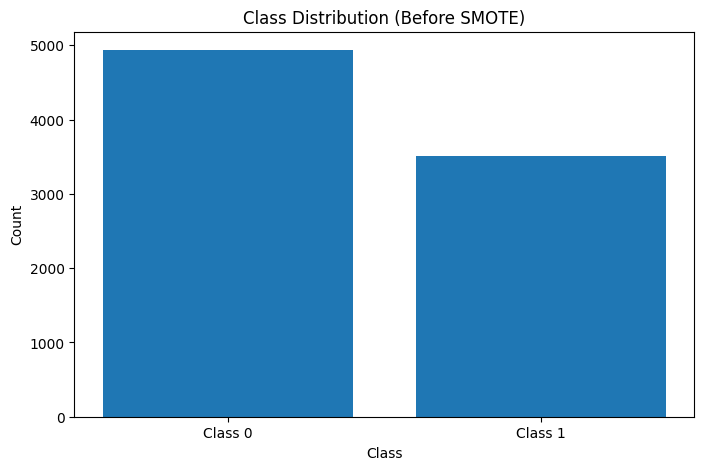

Applying SMOTE...
After SMOTE:
Label
0    4936
1    4936
Name: count, dtype: int64

Final dataset shape: (9872, 24)
Sample of final data:
   Flow Duration  Total Fwd Packets  Total Backward Packets  \
0   1.644974e-08           0.003225                0.062147   
1   3.096186e-08           0.001488                0.031943   
2   2.571141e-08           0.001408                0.026510   
3   3.360669e-10           0.000010                0.000217   
4   8.508666e-08           0.005023                0.103651   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                     0.001642                     0.037665   
1                     0.000865                     0.001418   
2                     0.000789                     0.001213   
3                     0.000009                     0.000006   
4                     0.002925                     0.004086   

   Fwd Packet Length Std  Bwd Packet Length Min  Bwd Packet Length Std  \
0               0.055630      

In [ ]:
# Apply SMOTE and Save
FINAL_OUTPUT_PATH = r'dataset\parquet\final_labeled_flow_logs.parquet'
df_final = apply_smote_and_save(df_cleaned, FINAL_OUTPUT_PATH)

In [1]:
import joblib

scaler = joblib.load("model/scaler.joblib")

print(type(scaler))

<class 'sklearn.preprocessing._data.MinMaxScaler'>
